# 📘 Session 1: Defensive Structures & Lines — Exercises

---

# 🏟️ Part A. Defensive Lines in a Single Frame

## **Task A1.** Pick a random frame where your target team (e.g., *Real Madrid*) is defending.  
- Plot the freeze-frame on the pitch.  
- Add the **defensive line (2nd deepest defender)**.  
- Does it match your football intuition?




In [3]:
# Import libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mplsoccer import Pitch
from sklearn.cluster import KMeans

# Set up paths
BASE_DIR = Path.cwd().parent / "RealMadrid"
PROCESSED_DIR = BASE_DIR / "processed"
META_DIR = BASE_DIR / "meta"
FREEZE_PARQUET = PROCESSED_DIR / 'freeze_frames_all.parquet'

# Pitch dimensions (StatsBomb convention)
PITCH_LENGTH = 105
PITCH_WIDTH = 68

# Target team
TARGET_TEAM = "Real Madrid"

print("✅ Libraries imported successfully")
print(f"📂 Base directory: {BASE_DIR}")
print(f"📄 Freeze frames path: {FREEZE_PARQUET}")

✅ Libraries imported successfully
📂 Base directory: /home/macaco3001/Projectos/Twelve/twelve-deep-learning/RealMadrid
📄 Freeze frames path: /home/macaco3001/Projectos/Twelve/twelve-deep-learning/RealMadrid/processed/freeze_frames_all.parquet


In [4]:
# Load freeze frames data
print("📥 Loading freeze frames...")
df_freeze = pd.read_parquet(FREEZE_PARQUET)

print(f"✅ Loaded {len(df_freeze):,} freeze frame rows")
print(f"   Unique matches: {df_freeze['match_id'].nunique()}")
print(f"   Unique events: {df_freeze['event_id'].nunique():,}")
print(f"   Memory usage: {df_freeze.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Display sample
df_freeze.head()

📥 Loading freeze frames...
✅ Loaded 2,443,620 freeze frame rows
   Unique matches: 98
   Unique events: 1,512
✅ Loaded 2,443,620 freeze frame rows
   Unique matches: 98
   Unique events: 1,512
   Memory usage: 2334.9 MB
   Memory usage: 2334.9 MB


,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,...,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,1021404,00:00:03.10,41,1,13899,False,False,-38.25,0.84,8_0,...,Unai Simón,273.0,Athletic Club de Bilbao,Athletic Bilbao,Other,Goalkeeper,13.882212,34.84,56.942308,35.05
1,1021404,00:00:03.10,41,1,13903,False,False,-20.35,-5.84,8_0,...,Dani Vivian,273.0,Athletic Club de Bilbao,Athletic Bilbao,Central Defender,Right Center Back,31.954327,28.16,56.942308,35.05
2,1021404,00:00:03.10,41,1,32276,False,False,-20.71,6.49,8_0,...,Aitor Paredes,273.0,Athletic Club de Bilbao,Athletic Bilbao,Central Defender,Left Center Back,31.590865,40.49,56.942308,35.05
3,1021404,00:00:03.10,41,1,8259,False,False,-3.64,-19.77,8_0,...,Óscar De Marcos,273.0,Athletic Club de Bilbao,Athletic Bilbao,Full Back,Right Back,48.825000,14.23,56.942308,35.05
4,1021404,00:00:03.10,41,1,4463,False,False,-16.72,12.00,8_0,...,Íñigo Lekue,273.0,Athletic Club de Bilbao,Athletic Bilbao,Full Back,Left Back,35.619231,46.00,56.942308,35.05


In [5]:
def plot_defensive_line(frame_df, defending_team_name, defend_left=True):
    """
    Plot players on the pitch and add a dashed line for the last defender
    (2nd deepest player) of the defending_team.

    Parameters
    ----------
    frame_df : pd.DataFrame
        Freeze-frame tracking data for a single frame. Must contain:
        - x_rescaled, y_rescaled (mplsoccer coordinates: 0-105 x 0-68)
        - is_ball (True/False)
        - player_team_name
    defending_team_name : str
        The actual team name (e.g. "Real Madrid CF") to evaluate.
    defend_left : bool, default=True
        If True, team defends the left goal (x close to 0).
        If False, team defends the right goal (x close to 105).
    """
    frame_df = frame_df.copy()
    
    # Defensive players (exclude ball)
    defenders = frame_df[
        (frame_df["player_team_name"] == defending_team_name) & (frame_df["is_ball"] == False)
    ]
    
    if defenders.empty:
        print(f"No defenders found for {defending_team_name} in this frame")
        return
    
    # Sort defenders based on defending direction
    if defend_left:
        sorted_defenders = defenders.sort_values("x_rescaled")  # left side → smallest x
    else:
        sorted_defenders = defenders.sort_values("x_rescaled", ascending=False)  # right side → largest x
    
    # Defensive line = 2nd deepest player
    if len(sorted_defenders) >= 2:
        last_defender_x = sorted_defenders.iloc[1]["x_rescaled"] if defend_left else sorted_defenders.iloc[1]["x_rescaled"]
    else:
        last_defender_x = np.nan
    
    # --- Plotting ---
    pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
    fig, ax = pitch.draw(figsize=(9,6))
    
    # Plot ball
    ball = frame_df[frame_df["is_ball"]]
    ax.scatter(ball["x_rescaled"], ball["y_rescaled"], c="red", s=120, edgecolors="k", label="Ball")
    
    # Plot players by team
    for team, group in frame_df.groupby("player_team_name"):
        ax.scatter(group["x_rescaled"], group["y_rescaled"], s=80, alpha=0.9, edgecolors="k", label=team)
    
    # Defensive line
    if not np.isnan(last_defender_x):
        ax.axvline(last_defender_x, color="black", linestyle="--", linewidth=2, label="Defensive line")
    
    ax.set_title(f"Defensive line of {defending_team_name}", fontsize=14)
    ax.legend()
    plt.show()


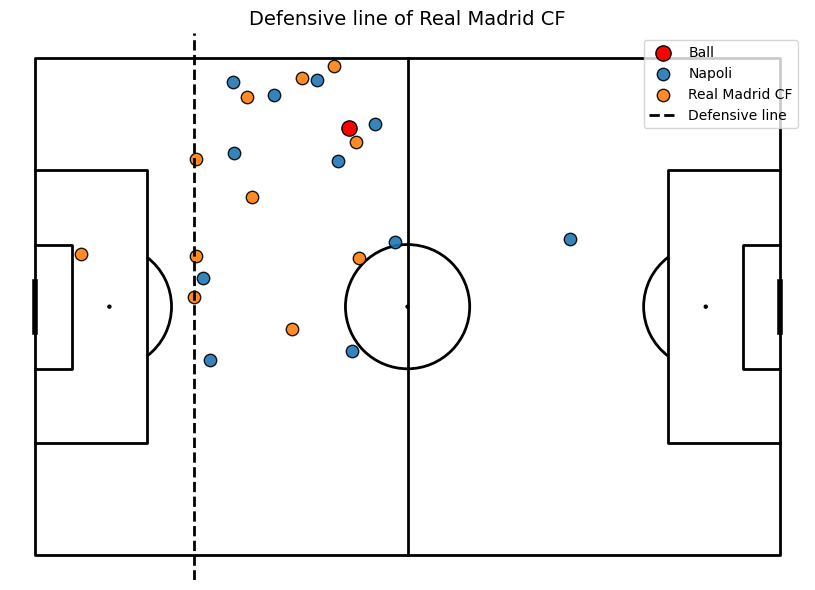

In [7]:
# Pick a random frame
random_row = df_freeze.sample(1).iloc[0]
match_id = random_row["match_id"]
frame_no = random_row["frame"]

frame_example = df_freeze[
    (df_freeze["match_id"] == match_id) &
    (df_freeze["frame"] == frame_no)
]

# Pick defending team from this frame
defending_team = frame_example.loc[~frame_example["is_ball"], "player_team_name"].unique()[0]

# Plot
plot_defensive_line(frame_example, defending_team_name=defending_team, defend_left=True)



## Task A2. Extend the visualization to plot all 3 defensive lines (using clustering).

Do the vertical dashed lines align with the player positions?

# HINT:
frame_example = rm_def_rows.sample(1, random_state=99)
frame_labeled = assign_defensive_lines_in_frame(frame_example)


## Task A3. Label each Real Madrid defender with their line_id.

Which players are in the deepest line?

Which are further up the pitch?

# 🧩 Part B. Season-Wide Defensive Trends

## Task B1. Compute the average depth (x position) of each defensive line per match.

Plot as a time series across matches.

Which matches show Real Madrid defending deeper than usual?

In [ ]:
# HINT:
line_depths = (
    rm_def_rows.groupby(["match_id","def_line_id"])["x_norm"].mean().unstack()
)


Task B2. Compare Real Madrid’s average line depths against 3 different opponents.

Do they defend higher against weaker teams?

Do they sit deeper against stronger opponents?

## Task B3. Plot a boxplot of defensive line depths across all matches.

Which defensive line (1, 2, or 3) shows the greatest variation?

What might this mean tactically?

# 🎯 Part C. Compactness & Shape

## Task C1. Compute the spread (standard deviation of y positions) of each line.

Which line is most compact?

Does compactness change depending on match context?

## Task C2. (Challenge) Compare Real Madrid’s compactness in the first half vs second half.

Do they get stretched later in matches?

## Task C3. (Open-Ended) Find one example frame where the defensive lines look very compact and another where they are very stretched.

Plot both frames.

Discuss what might have caused this difference.

# 🏁 Wrap-Up Reflection

- How consistent are Real Madrid’s defensive lines across matches?

- When do they defend higher vs deeper?

- Do the defensive line statistics match what you see on the pitch?